In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
ls


sample_data/


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/Sentiment_Data.zip", encoding='ISO-8859-1')
print(data.info())
print(data['Sentiment'].value_counts())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451332 entries, 0 to 451331
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Tweet      451331 non-null  object
 1   Sentiment  451332 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB
None
Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [5]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 12.5 MB/s eta 0:00:00


In [6]:
import pandas as pd
import re
import emoji
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size=0.3, stratify=data['Sentiment'], random_state=42)

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")
print("Train label distribution:\n", train_df['Sentiment'].value_counts(normalize=True))
print("Test label distribution:\n", test_df['Sentiment'].value_counts(normalize=True))


Train size: 315932, Test size: 135400
Train label distribution:
 Sentiment
Strong_Pos    0.517801
Neutral       0.170641
Mild_Pos      0.141812
Strong_Neg    0.094289
Mild_Neg      0.075456
Name: proportion, dtype: float64
Test label distribution:
 Sentiment
Strong_Pos    0.517799
Neutral       0.170643
Mild_Pos      0.141809
Strong_Neg    0.094291
Mild_Neg      0.075458
Name: proportion, dtype: float64


In [7]:
# Regex Cleaning
def regex_clean(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)       # Remove URLs
    text = re.sub(r'@\w+', '', text)                        # Remove mentions
    text = re.sub(r'#\w+', '', text)                        # Remove hashtags
    text = re.sub(r'[^\w\s]', '', text)                     # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                # Remove extra spaces
    return text

# Emoji Handling
def handle_emojis(text):
    return emoji.demojize(text, delimiters=(" ", " "))

# Slang Replacement
slang_dict = {
    "idk": "i do not know", "lol": "laugh out loud", "omg": "oh my god",
    "brb": "be right back", "btw": "by the way", "ttyl": "talk to you later",
    "imo": "in my opinion", "fyi": "for your information", "smh": "shaking my head",
    "tbh": "to be honest", "lmao": "laughing my ass off", "rofl": "rolling on the floor laughing",
    "np": "no problem", "yw": "you are welcome", "bff": "best friends forever",
    "afaik": "as far as i know", "ikr": "i know right", "jk": "just kidding",
    "nvm": "never mind", "omw": "on my way", "thx": "thanks", "ty": "thank you",
    "gr8": "great", "plz": "please", "wtf": "what the fuck", "wth": "what the hell",
    "fomo": "fear of missing out", "irl": "in real life", "tmi": "too much information",
    "cya": "see you", "cu": "see you", "dm": "direct message", "ftw": "for the win",
    "ftl": "for the loss", "gg": "good game", "gl": "good luck", "wyd": "what are you doing",
    "yolo": "you only live once"
}

def replace_slangs(text):
    words = text.split()
    return " ".join([slang_dict.get(w, w) for w in words])

# Negation Handling
def negation_handling(text):
    negation_words = {'not', 'no', 'never', "n't"}
    tokens = text.split()
    new_tokens = []
    negate = False
    count = 0
    for token in tokens:
        if token in negation_words:
            negate = True
            count = 0
            new_tokens.append(token)
        elif negate:
            new_tokens.append("not_" + token)
            count += 1
            if count >= 5:
                negate = False
        else:
            new_tokens.append(token)
    return " ".join(new_tokens)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = regex_clean(text)
    text = handle_emojis(text)
    text = replace_slangs(text)
    text = negation_handling(text)
    return text

# Label Mapping Function
def map_sentiment(label):
    mapping = {
        'Strong_Pos': 'Positive',
        'Mild_Pos': 'Positive',
        'Neutral': 'Neutral',
        'Mild_Neg': 'Negative',
        'Strong_Neg': 'Negative'
    }
    return mapping.get(label, label)

In [8]:
train_df['cleaned'] = train_df['Tweet'].fillna('').astype(str).apply(preprocess_text)
test_df['cleaned'] = test_df['Tweet'].fillna('').astype(str).apply(preprocess_text)

# Map labels to 3 classes
train_df['Sentiment'] = train_df['Sentiment'].apply(map_sentiment)
test_df['Sentiment'] = test_df['Sentiment'].apply(map_sentiment)

# Confirm mapping worked
print(train_df['Sentiment'].value_counts())
print(test_df['Sentiment'].value_counts())

Sentiment
Positive    208393
Neutral      53911
Negative     53628
Name: count, dtype: int64
Sentiment
Positive    89311
Neutral     23105
Negative    22984
Name: count, dtype: int64


In [9]:
print(train_df[['Tweet', 'cleaned', 'Sentiment']].head())
print(test_df[['Tweet', 'cleaned', 'Sentiment']].head())

# Save if needed
train_df.to_csv('train_preprocessed.csv', index=False)
test_df.to_csv('test_preprocessed.csv', index=False)


                                                    Tweet  \
127180  @sheepkingjb @CarymaRules Iâve seen this guy...   
92417   @RobertFife To Robert fife . This had nothing ...   
351847  This thread\n\n#ThanksJoeRogan #FreedomConvoy2...   
188891  Patriots line the route to show support for th...   
124760  Oath Keepers, anti-democracy activists, and ot...   

                                                  cleaned Sentiment  
127180  iâve seen this guy in a video wearing a kilt a...  Positive  
92417   to robert fife this had nothing to do withthe ...  Positive  
351847                                        this thread   Neutral  
188891  patriots line the route to show support for th...  Positive  
124760  oath keepers antidemocracy activists and other...   Neutral  
                                                    Tweet  \
155192  Ottawa Police chief admits no firearms discove...   
85987   @DebbieSammit @Bunnyhug123 @JeffreyLuscombe @P...   
87607   @roulinski @CPC_HQ @Pi

In [10]:
import pandas as pd

train_df = pd.read_csv('train_preprocessed.csv')
test_df = pd.read_csv('test_preprocessed.csv')

print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

Train samples: 315932, Test samples: 135400


In [11]:
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())


Train columns: ['Tweet', 'Sentiment', 'cleaned']
Test columns: ['Tweet', 'Sentiment', 'cleaned']


In [12]:
pip install torch scikit-learn pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [13]:
import torch
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        # Ensure <pad> and <unk> are in vocab
        if "<pad>" not in self.vocab:
            self.vocab["<pad>"] = 0
        if "<unk>" not in self.vocab:
             # Assign the next available index for <unk>
            self.vocab["<unk>"] = len(self.vocab)

        print(f"SentimentDataset initialized with vocab size: {len(self.vocab)}") # Add this print statement


    def __len__(self):
        return len(self.texts)

    def encode_text(self, text):
        tokens = text.lower().split()
        # Use vocab.get with a default of <unk> index
        token_ids = []
        for tok in tokens:
            token_id = self.vocab.get(tok, self.vocab["<unk>"])
            # Add this print for debugging
            # print(f"Token: '{tok}', Generated index: {token_id}, Vocab size: {len(self.vocab)}")
            if token_id >= len(self.vocab):
                print(f"Warning: Token '{tok}' generated out-of-range index {token_id} (vocab size: {len(self.vocab)})")
                token_ids.append(self.vocab["<unk>"]) # Fallback to <unk>
            else:
                token_ids.append(token_id)


        # Pad or truncate
        token_ids = token_ids[:self.max_len] + [self.vocab["<pad>"]] * (self.max_len - len(token_ids))
        return torch.tensor(token_ids)


    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoded_text = self.encode_text(text)
        # Add this print statement for debugging
        # print(f"Item {idx}: Encoded text min: {encoded_text.min().item()}, max: {encoded_text.max().item()}")
        return encoded_text, torch.tensor(label)

In [14]:
# Convert non-string cleaned texts to empty strings
train_df['cleaned'] = train_df['cleaned'].fillna('').astype(str)
test_df['cleaned'] = test_df['cleaned'].fillna('').astype(str)


In [15]:
def encode_text(self, text):
    if not isinstance(text, str):
        text = ""
    tokens = text.lower().split()
    token_ids = [self.vocab.get(tok, self.vocab["<unk>"]) for tok in tokens]
    token_ids = token_ids[:self.max_len] + [self.vocab["<pad>"]] * (self.max_len - len(token_ids))
    return torch.tensor(token_ids)


In [16]:
# First, define the function
def build_vocab(texts, min_freq=2):
    from collections import Counter
    vocab = Counter()
    for text in texts:
        vocab.update(text.split())
    return {word: idx + 2 for idx, (word, count) in enumerate(vocab.items()) if count >= min_freq}

# Then call it
vocab = build_vocab(train_df['cleaned'])


In [17]:
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# Load cleaned data
train_df = pd.read_csv("train_preprocessed.csv")
test_df = pd.read_csv("test_preprocessed.csv")

# Label encode sentiments
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['Sentiment'])
test_df['label'] = le.transform(test_df['Sentiment'])

train_df['cleaned'] = train_df['cleaned'].fillna('').astype(str)
test_df['cleaned'] = test_df['cleaned'].fillna('').astype(str)


# Build vocab
def build_vocab1(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(text.lower().split())

    # Assign indices starting from 2 for words with frequency >= min_freq
    vocab = {word: idx + 2 for idx, (word, freq) in enumerate(counter.items()) if freq >= min_freq}

    # Explicitly add <pad> and <unk> with reserved indices 0 and 1
    vocab["<pad>"] = 0
    vocab["<unk>"] = 1

    return vocab


vocab = build_vocab(train_df['cleaned'])

def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        if isinstance(text, str):
            counter.update(text.lower().split())

    vocab = {"<pad>": 0, "<unk>": 1}
    index = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = index
            index += 1
    return vocab


# Print vocabulary size and a sample
print(f"Vocabulary size after building: {len(vocab)}")
print("Sample vocabulary items:", list(vocab.items())[:20])


# Datasets and Loaders
max_len = 50
train_dataset = SentimentDataset(train_df['cleaned'].tolist(), train_df['label'].tolist(), vocab, max_len)
test_dataset = SentimentDataset(test_df['cleaned'].tolist(), test_df['label'].tolist(), vocab, max_len)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

Vocabulary size after building: 65864
Sample vocabulary items: [('iâve', 2), ('seen', 3), ('this', 4), ('guy', 5), ('in', 6), ('a', 7), ('video', 8), ('wearing', 9), ('kilt', 10), ('at', 11), ('freedom', 12), ('convoy', 13), ('protest', 14), ('to', 15), ('robert', 16), ('fife', 17), ('had', 18), ('nothing', 19), ('do', 20), ('withthe', 21)]
SentimentDataset initialized with vocab size: 65866
SentimentDataset initialized with vocab size: 65866


In [18]:
import torch.nn as nn

class NonCausalTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, num_classes, max_len):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(max_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads,
                                                   dim_feedforward=ff_dim, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(ff_dim, num_classes)
        )
        print(f"NonCausalTransformer initialized with vocab_size: {vocab_size}, embedding layer size: {self.token_embed.num_embeddings}") # Add this print statement

    def forward(self, x):
        # print("Input tensor min:", x.min().item(), "max:", x.max().item(), "vocab size:", self.token_embed.num_embeddings) # Add this line
        pos = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        x = self.token_embed(x) + self.pos_embed(pos)
        x = self.encoder(x)
        x = x.mean(dim=1)  # Global average pooling
        return self.classifier(x)

In [19]:
def train_model(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        # Add this print statement
        print("Input batch min:", x.min().item(), "max:", x.max().item())
        # Explicitly send input tensor to CPU
        x = x.to("cpu")
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_model(model, loader, criterion, device):
    model.eval()
    correct = total = 0
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item()
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return total_loss / len(loader), correct / total

In [20]:
# Assume <PAD> = 0, <UNK> = 1 already defined in vocab

def encode_text(text, vocab):
    return [vocab.get(word, vocab['<UNK>']) for word in text.split()]


In [21]:
vocab = {'<PAD>': 0, '<UNK>': 1}
vocab.update(build_vocab(train_df['cleaned']))


In [22]:
def build_vocab(texts, min_freq=2):
    from collections import Counter
    vocab_counter = Counter()
    for text in texts:
        vocab_counter.update(text.split())
    return {
        word: idx + 2  # +2 to leave space for <PAD>=0, <UNK>=1
        for idx, (word, count) in enumerate(vocab_counter.items())
        if count >= min_freq
    }


In [23]:
vocab = {'<PAD>': 0, '<UNK>': 1}
vocab.update(build_vocab(train_df['cleaned']))


In [24]:
def encode_text(text, vocab):
    return [vocab.get(token, vocab['<UNK>']) for token in text.split()]


In [25]:
encoded_texts = [encode_text(text, vocab) for text in train_df['cleaned']]


In [26]:
def encode_text(text, vocab):
    return [vocab.get(token, vocab['<UNK>']) for token in text.split()]


In [27]:
all_encoded = [encode_text(text, vocab) for text in train_df['cleaned']]
max_index = max([max(seq) if len(seq) > 0 else 0 for seq in all_encoded])
min_index = min([min(seq) if len(seq) > 0 else 0 for seq in all_encoded])
print(f"Min index: {min_index}, Max index: {max_index}, Vocab size: {len(vocab)}")


Min index: 0, Max index: 163747, Vocab size: 65866


In [28]:
from collections import Counter

def build_vocab(texts, min_freq=2):
    vocab_counter = Counter()
    for text in texts:
        vocab_counter.update(text.split())

    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, count in vocab_counter.items():
        if count >= min_freq:
            vocab[word] = len(vocab)
    return vocab


In [29]:
def encode_text(text, vocab):
    return [vocab.get(token, vocab['<UNK>']) for token in text.split()]


In [30]:
# Assuming your text column is train_df['cleaned']
vocab = build_vocab(train_df['cleaned'])
encoded_texts = [encode_text(text, vocab) for text in train_df['cleaned']]


In [31]:
# Ensure '<UNK>' is in your vocab
if '<UNK>' not in vocab:
    vocab['<UNK>'] = len(vocab)

# Define a safe encoding function
def encode_text(text, vocab):
    if isinstance(text, str):
        tokens = text.split()
        return [vocab.get(token, vocab['<UNK>']) for token in tokens]
    else:
        return [vocab['<UNK>']]


In [32]:
print(data.columns)


Index(['Tweet', 'Sentiment'], dtype='object')


In [33]:
import re

def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'https?://\S+|www\.\S+', '', text)  # remove URLs
        text = re.sub(r'@\w+|#\w+', '', text)  # remove mentions and hashtags
        text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation and special chars
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    else:
        return ""


In [34]:
import pandas as pd
import re
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the data
data = pd.read_csv("/content/drive/MyDrive/Sentiment_Data.zip", encoding='ISO-8859-1')

# Step 1: Clean the Tweet text
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'https?://\S+|www\.\S+', '', text)  # remove URLs
        text = re.sub(r'@\w+|#\w+', '', text)              # remove mentions and hashtags
        text = re.sub(r'[^a-z\s]', '', text)               # remove special characters
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    else:
        return ""

data['Cleaned_Text'] = data['Tweet'].apply(clean_text)

# Step 2: Ensure vocab and <UNK> token exist
if '<UNK>' not in vocab:
    vocab['<UNK>'] = len(vocab)

# Step 3: Encode text safely
def encode_text(text, vocab):
    tokens = text.split()
    return [vocab.get(token, vocab['<UNK>']) for token in tokens]

encoded_sequences = [encode_text(text, vocab) for text in data['Cleaned_Text']]

# Step 4: Pad sequences
max_len = max(len(seq) for seq in encoded_sequences)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Step 5: Debug print
print(" Cleaned and encoded successfully")
print("Max index in encoded data:", max([max(seq) for seq in padded_sequences]))
print("Vocab size:", len(vocab))


 Cleaned and encoded successfully
Max index in encoded data: 65864
Vocab size: 65866


In [36]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(data['Sentiment'])


In [37]:
print("Unique label values:", set(encoded_labels))
print("Number of classes:", len(label_encoder.classes_))


Unique label values: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Number of classes: 5


In [38]:
# --- [1] Imports ---
import pandas as pd
import re
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- [2] Load and Clean Data ---
data = pd.read_csv("/content/drive/MyDrive/Sentiment_Data.zip", encoding='ISO-8859-1')

def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)
        text = re.sub(r'[^a-z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    else:
        return ""

data['Cleaned_Text'] = data['Tweet'].apply(clean_text)

# --- [3] Create vocab (or use existing one) ---
# Example: Build vocab from data
from collections import Counter

tokenized = [text.split() for text in data['Cleaned_Text']]
word_counts = Counter(token for tokens in tokenized for token in tokens)

vocab = {'<PAD>': 0, '<UNK>': 1}
for i, word in enumerate(word_counts.keys(), start=2):
    vocab[word] = i

# --- [4] Encode Text Safely ---
if '<UNK>' not in vocab:
    vocab['<UNK>'] = len(vocab)

def encode_text(text, vocab):
    tokens = text.split()
    return [vocab.get(token, vocab['<UNK>']) for token in tokens]

encoded_sequences = [encode_text(text, vocab) for text in data['Cleaned_Text']]
max_len = max(len(seq) for seq in encoded_sequences)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# --- [5] Encode Labels ---
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(data['Sentiment'])

print("Unique label values:", set(encoded_labels))
print("Number of classes:", len(label_encoder.classes_))

# --- [6] Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, encoded_labels, test_size=0.2,
    stratify=encoded_labels, random_state=42
)

# --- [7] Convert to Torch tensors ---
X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


Unique label values: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Number of classes: 5


#Tuning!

In [39]:
le = LabelEncoder()
le.fit(train_df['Sentiment'].tolist() + test_df['Sentiment'].tolist())
train_df['label'] = le.transform(train_df['Sentiment'])
test_df['label'] = le.transform(test_df['Sentiment'])

In [40]:
def build_vocab_tune(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        if isinstance(text, str):
            counter.update(text.lower().split())

    vocab = {"<pad>": 0, "<unk>": 1}
    idx = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

vocab_tune = build_vocab_tune(train_df['cleaned'])
vocab_size = max(vocab.values()) + 1
max_len = 100

In [41]:
# --- Dataset Class ---
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def encode_text(self, text):
        if not isinstance(text, str):
            text = ""
        tokens = text.lower().split()
        token_ids = [self.vocab.get(tok, self.vocab["<unk>"]) for tok in tokens]
        token_ids = token_ids[:self.max_len] + [self.vocab["<pad>"]] * (self.max_len - len(token_ids))
        return torch.tensor(token_ids)

    def __getitem__(self, idx):
        x = self.encode_text(self.texts[idx])
        y = torch.tensor(self.labels[idx])
        return x, y

In [42]:
_dataset = TextDataset(train_df['cleaned'].tolist(), train_df['label'].tolist(), vocab_tune, max_len)
test_dataset = TextDataset(test_df['cleaned'].tolist(), test_df['label'].tolist(), vocab_tune, max_len)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [43]:
# --- Model ---
class NonCausalTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, num_classes, max_len):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(max_len, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(0.3)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, num_classes)
        )

    def forward(self, x):
        pos = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        x = self.token_embed(x) + self.pos_embed(pos)
        x = self.encoder(x)
        x = x.mean(dim=1)  # Global average pooling
        x = self.norm(self.dropout(x))
        return self.classifier(x)

In [44]:
# --- Training ---
device = torch.device("cpu")

model = NonCausalTransformer(vocab_size, 128, 4, 256, 2, len(le.classes_), max_len).to(device)

In [45]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
class_weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [46]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [49]:
# --- [1] Imports ---
import pandas as pd
import re
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from collections import Counter

# --- [2] Load and Clean Data ---
data = pd.read_csv("/content/drive/MyDrive/Sentiment_Data.zip", encoding='ISO-8859-1')

def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)
        text = re.sub(r'[^a-z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    else:
        return ""

data['Cleaned_Text'] = data['Tweet'].apply(clean_text)

# --- [3] Build Vocab ---
tokenized = [text.split() for text in data['Cleaned_Text']]
word_counts = Counter(token for tokens in tokenized for token in tokens)

vocab = {'<PAD>': 0, '<UNK>': 1}
for i, word in enumerate(word_counts.keys(), start=2):
    vocab[word] = i

if '<UNK>' not in vocab:
    vocab['<UNK>'] = len(vocab)

# --- [4] Encode Text Safely ---
def encode_text(text, vocab):
    if isinstance(text, str) and text.strip():
        tokens = text.split()
        return [vocab.get(token, vocab['<UNK>']) for token in tokens if token.strip()]
    else:
        return [vocab['<UNK>']]

encoded_sequences = [encode_text(text, vocab) for text in data['Cleaned_Text']]
encoded_sequences = [seq for seq in encoded_sequences if len(seq) > 0]

# --- [5] Padding and Sanity Check ---
max_len = min(100, max(len(seq) for seq in encoded_sequences))  # capped at 100
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

max_token_id = max([max(seq) for seq in encoded_sequences])
print("Max token index in encoded data:", max_token_id)
print("Vocab size:", len(vocab))

# --- [6] Encode Labels ---
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(data['Sentiment'])

print("Unique label values:", set(encoded_labels))
print("Number of classes:", len(label_encoder.classes_))

# --- [7] Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, encoded_labels, test_size=0.2,
    stratify=encoded_labels, random_state=42
)

# --- [8] Torch Tensors and DataLoaders ---
X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32)

# --- [9] Define NonCausalTransformer Model ---
class NonCausalTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, num_classes, max_len):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(max_len, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(ff_dim, num_classes)
        )

    def forward(self, x):
        pos = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        x = self.token_embed(x) + self.pos_embed(pos)
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.classifier(x)

# --- [10] Train/Eval Functions ---
def train_model(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for i, (X_batch, y_batch) in enumerate(dataloader):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if i % 10 == 0:
            print(f"  Batch {i}/{len(dataloader)} - Loss: {loss.item():.4f}")
    return total_loss / len(dataloader)

def eval_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / len(dataloader), correct / total

# --- [11] Initialize and Train Model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = NonCausalTransformer(
    vocab_size=len(vocab),
    embed_dim=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    num_classes=len(label_encoder.classes_),
    max_len=max_len
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

for epoch in range(1):  # run just 1 epoch to test speed
    print(f"\nEpoch {epoch+1}")
    train_loss = train_model(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_model(model, test_loader, criterion, device)
    print(f"Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")


Max token index in encoded data: 140167
Vocab size: 140168
Unique label values: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Number of classes: 5
Using device: cuda

Epoch 1
  Batch 0/11284 - Loss: 1.6285
  Batch 10/11284 - Loss: 1.5230
  Batch 20/11284 - Loss: 1.2216
  Batch 30/11284 - Loss: 1.2962
  Batch 40/11284 - Loss: 1.1374
  Batch 50/11284 - Loss: 1.3454
  Batch 60/11284 - Loss: 1.4052
  Batch 70/11284 - Loss: 1.2120
  Batch 80/11284 - Loss: 1.3234
  Batch 90/11284 - Loss: 1.4259
  Batch 100/11284 - Loss: 1.3387
  Batch 110/11284 - Loss: 1.2638
  Batch 120/11284 - Loss: 1.3147
  Batch 130/11284 - Loss: 1.3849
  Batch 140/11284 - Loss: 1.4460
  Batch 150/11284 - Loss: 1.4159
  Batch 160/11284 - Loss: 1.3280
  Batch 170/11284 - Loss: 1.3094
  Batch 180/11284 - Loss: 1.2843
  Batch 190/11284 - Loss: 1.1229
  Batch 200/11284 - Loss: 1.1047
  Batch 210/11284 - Loss: 1.2706
  Batch 220/11284 - Loss: 1.4441
  Batch 230/11284 - Loss: 1.2080
  Batch 240/11284 - Loss

In [50]:
# --- Evaluation ---
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        preds = model(x_batch).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

In [53]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [55]:
print("Pred classes:", set(all_preds))
print("True classes:", set(all_labels))
print("Target names:", label_encoder.classes_)


Pred classes: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
True classes: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Target names: ['Mild_Neg' 'Mild_Pos' 'Neutral' 'Strong_Neg' 'Strong_Pos']


Classification Report:

              precision    recall  f1-score   support

    Mild_Neg       0.44      0.09      0.15      6811
    Mild_Pos       0.52      0.29      0.37     12801
     Neutral       0.62      0.49      0.55     15403
  Strong_Neg       0.41      0.65      0.50      8511
  Strong_Pos       0.75      0.90      0.82     46741

    accuracy                           0.66     90267
   macro avg       0.55      0.48      0.48     90267
weighted avg       0.64      0.66      0.63     90267



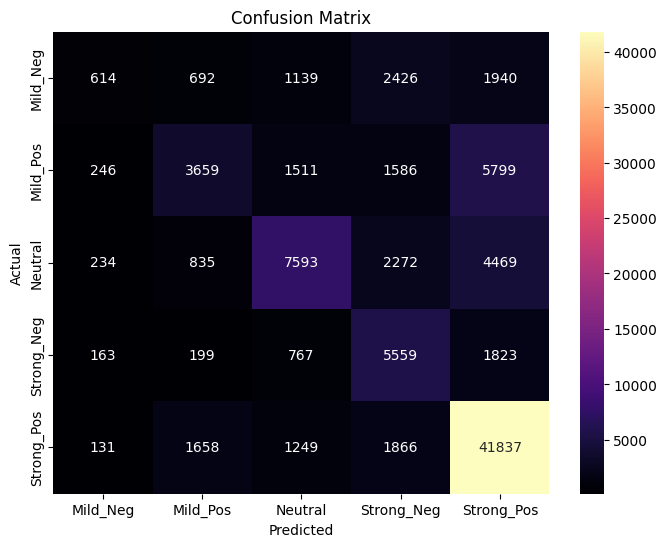

In [56]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Get predictions and true labels from test_loader
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

# Step 2: Classification report
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

# Step 3: Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap="magma")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [58]:
# --- Evaluation Function ---
def eval_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / len(dataloader), correct / total


In [59]:
val_loss, val_acc = eval_model(model, test_loader, criterion, device)
print(f"Model - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Model - Val Loss: 0.9424, Val Acc: 0.6565


cross validation

In [60]:
from sklearn.model_selection import StratifiedKFold
import numpy as np


In [64]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Use smaller tensors for testing fast
X = np.array(padded_sequences)
y = np.array(encoded_labels)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3 folds for speed

fold_accuracies = []
fold = 1

for train_idx, val_idx in skf.split(X, y):
    print(f"\n Fold {fold}:")

    # Subset for this fold
    X_train_fold = torch.tensor(X[train_idx], dtype=torch.long)
    y_train_fold = torch.tensor(y[train_idx], dtype=torch.long)
    X_val_fold = torch.tensor(X[val_idx], dtype=torch.long)
    y_val_fold = torch.tensor(y[val_idx], dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_fold, y_train_fold), batch_size=16, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_fold, y_val_fold), batch_size=16)

    # Lightweight model
    model = NonCausalTransformer(
        vocab_size=len(vocab),
        embed_dim=64,           # smaller
        num_heads=2,
        ff_dim=128,             # smaller
        num_layers=1,           # smaller
        num_classes=len(label_encoder.classes_),
        max_len=min(100, max_len)  # capped at 100
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Only 1 epoch per fold (initial run)
    for epoch in range(1):
        train_loss = train_model(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = eval_model(model, val_loader, criterion, device)
        print(f"  Fold {fold} → Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")

    fold_accuracies.append(val_acc)
    fold += 1

# Summary
print(f"\n Average Accuracy: {np.mean(fold_accuracies):.4f}")


Streaming output truncated to the last 5000 lines.
  Batch 6520/18806 - Loss: 0.6130
  Batch 6530/18806 - Loss: 1.6235
  Batch 6540/18806 - Loss: 1.0711
  Batch 6550/18806 - Loss: 0.9445
  Batch 6560/18806 - Loss: 0.8789
  Batch 6570/18806 - Loss: 1.0645
  Batch 6580/18806 - Loss: 1.5416
  Batch 6590/18806 - Loss: 1.0356
  Batch 6600/18806 - Loss: 1.1242
  Batch 6610/18806 - Loss: 1.3146
  Batch 6620/18806 - Loss: 1.2350
  Batch 6630/18806 - Loss: 1.1610
  Batch 6640/18806 - Loss: 1.3123
  Batch 6650/18806 - Loss: 1.4969
  Batch 6660/18806 - Loss: 1.0777
  Batch 6670/18806 - Loss: 1.4524
  Batch 6680/18806 - Loss: 0.9475
  Batch 6690/18806 - Loss: 0.8692
  Batch 6700/18806 - Loss: 0.8649
  Batch 6710/18806 - Loss: 1.3441
  Batch 6720/18806 - Loss: 1.0301
  Batch 6730/18806 - Loss: 0.9493
  Batch 6740/18806 - Loss: 1.2366
  Batch 6750/18806 - Loss: 1.1992
  Batch 6760/18806 - Loss: 0.7817
  Batch 6770/18806 - Loss: 1.0709
  Batch 6780/18806 - Loss: 1.2176
  Batch 6790/18806 - Loss: 1.30